<a href="https://colab.research.google.com/github/PioBasile/Classification-tweet-scientifique/blob/main/ProjetMachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
# Importation des librairies utilisées dans le notebook

# Masque les FutureWarning de scikit-learn
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Librairies générales
import pandas as pd          # Manipulation de tableaux
import numpy as np           # Calcul numérique
import string                # Gestion de chaînes
import re                    # Expressions régulières
import unicodedata           # Normalisation Unicode
#import contractions          # Gestion des contractions
from collections import Counter  # Comptage d'occurrences
from wordcloud import WordCloud         # Generation de nuages de mots

# Nettoyage de texte HTML
from bs4 import BeautifulSoup    # Parsing HTML

# Librairies d'affichage
import matplotlib.pyplot as plt  # Graphiques statiques
import plotly.graph_objs as go   # Graphiques avancés Plotly
import plotly.offline as py      # Mode offline Plotly
import plotly.express as px      # Visualisation rapide
import plotly.io as pio          # Sauvegarde d'images


# Librairies NLTK
import nltk                      # NLP basique
from nltk import sent_tokenize   # Découpage en phrases
from nltk import word_tokenize   # Découpage en mots
from nltk import pos_tag         # Étiquetage grammatical
from nltk.stem import WordNetLemmatizer   # Lemmatisation
from nltk.stem.snowball import SnowballStemmer   # Stemmatisation
from nltk.corpus import stopwords          # Stopwords

# Téléchargement des ressources NLTK
nltk.download("punkt")                      # Tokenisation
nltk.download("punkt_tab")                  # Tokenisation
nltk.download("averaged_perceptron_tagger") # Tags
nltk.download("averaged_perceptron_tagger_eng")  # Tags anglais
nltk.download("tagsets_json")               # Liste des tags
nltk.download("tagsets")                    # Ancienne liste
nltk.download("stopwords")                  # Stopwords
nltk.download("wordnet")                    # WordNet

# NLP avec SpaCy
import spacy                                # NLP avancé
from spacy import displacy                  # Visualisation
from spacy.lang.fr import French            # Modèle français

# Chargement du modèle anglais
nlp = spacy.load("en_core_web_sm")          # Modèle anglais


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets_json to /root/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading pac

In [42]:
from google.colab import drive
import pandas as pd
import re
import spacy
"""
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Téléchargement des ressources NLTK nécessaires
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
"""
# Avis de Reyder sur les algo de classification :
# K-NN : nul les tweet on des context different on ne peut pas les classer par similarité
# Naive Bayésiene : Bien, on a des classes précises et distincte
# Arbre décisionnel : Pas mal, mais il faudrait faire plein de sous classifications

drive.mount('/content/drive')
path = '/content/drive/MyDrive/ColabNotebooks/scitweets_export.tsv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Clean les Tweets

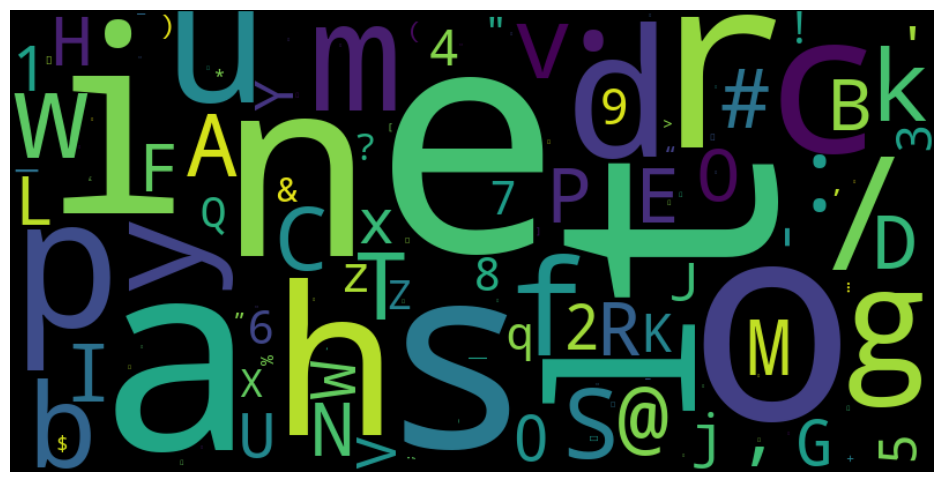

In [43]:
df = pd.read_csv(path, sep='\t')

all_words = df['text']
words = [word for sublist in all_words for word in sublist]

word_counts = Counter(words)

wc = WordCloud(width=800, height=400)         # Creation du word cloud
wc.generate_from_frequencies(word_counts)     # Generation

plt.figure(figsize=(12, 6))                   # Affichage
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

wc.to_file("wordcloud.png")

Resultat avant le pretraitement

In [44]:
df = pd.read_csv(path, sep='\t')

#traitement des émoticones
emoticons_str = r"""
    (?:
        [:=;] # Eyes
        [oO\-]? # Nose (optional)
        [D\)\]\(\]/\\OpP] # Mouth
    )"""

#Prise en compte des éléments qui doivent être regroupés
regex_str = [
    emoticons_str,
    r'<[^>]+>', # HTML tags
    r'(?:@[\w_]+)', # @-mentions
    r"(?:\#+[\w_]+[\w\'_\-]*[\w_]+)", # hash-tags
    r'http[s]?://(?:[a-z]|[0-9]|[$-_@.&amp;+]|[!*\(\),]|(?:%[0-9a-f][0-9a-f]))+', # URLs

    r'(?:(?:\d+,?)+(?:\.?\d+)?)', # nombres
    r"(?:[a-z][a-z'\-_]+[a-z])", # mots avec - et '
    r'(?:[\w_]+)', # autres mots
    r'(?:\S)' # le reste
]

tokens_re = re.compile(r'('+'|'.join(regex_str)+')', re.VERBOSE | re.IGNORECASE)
emoticon_re = re.compile(r'^'+emoticons_str+'$', re.VERBOSE | re.IGNORECASE)

def tokenize(s):
    return tokens_re.findall(s)

def preprocess(s, lowercase=False):
    tokens = tokenize(s)
    if lowercase:
        tokens = [
            tok if emoticon_re.search(tok) else tok.lower()
            for tok in tokens
        ]
    return tokens


In [45]:
contractions_map = {
    "don't": "do not",
    "doesn't": "does not",
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "you're": "you are",
    "they're": "they are",
    "we're": "we are",
}

def expand_contractions(text):
    # Normalisation simple des apostrophes typographiques
    text = text.replace("’", "'")
    tokens = text.split()
    expanded = []
    for t in tokens:
        key = t.lower()
        if key in contractions_map:
            expanded.extend(contractions_map[key].split())
        else:
            expanded.append(t)
    return " ".join(expanded)


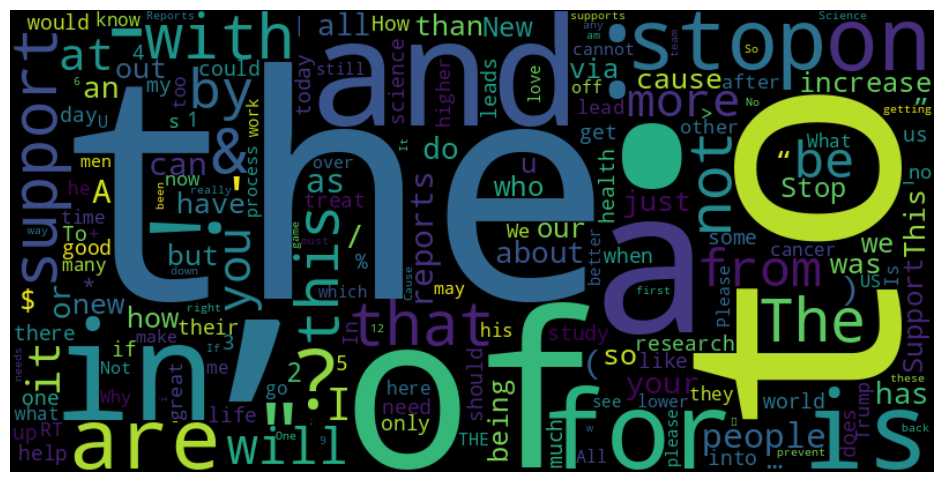

In [46]:
df['text_expanded'] = df['text'].apply(expand_contractions)
all_words_processed = df['text_expanded'].apply(preprocess)
words = [word for sublist in all_words_processed for word in sublist]

word_counts = Counter(words)

wc = WordCloud(width=800, height=400)         # Creation du word cloud
wc.generate_from_frequencies(word_counts)     # Generation

plt.figure(figsize=(12, 6))                   # Affichage
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

wc.to_file("wordcloud2.png")


# Classification

### Sac de mots

In [70]:
from sklearn.feature_extraction.text import CountVectorizer


#Code du cours
vectorizer = CountVectorizer(lowercase=False, stop_words="english", min_df=2, max_df=0.8, ngram_range=(1,1))
X = vectorizer.fit_transform(df["text"])

vocabulaire = vectorizer.get_feature_names_out()
print(vocabulaire[300:310])

print(X.shape)

#lowercase=False: Ne convertit pas en minuscules (respecte la casse).
#stop_words="english": Supprime les mots courants anglais (mots vides).
#min_df=2: Ignore les mots apparaissant dans moins de 2 documents.
#max_df=0.8: Ignore les mots apparaissant dans plus de 80% des documents.
#ngram_range=(1,1): N'extrait que des mots uniques (unigrammes).


['Indonesia' 'Industry' 'Instead' 'Institute' 'Interesting'
 'International' 'Iran' 'Is' 'Islam' 'Israel']
(1140, 1905)


##Pondération des mots

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer



#Code du cours
vectorizer = TfidfVectorizer(norm="l2",sublinear_tf=True,min_df=2, max_df=0.8, max_features=5000,ngram_range=(1,2))
X = vectorizer.fit_transform(df["text"])

vocabulaire = vectorizer.get_feature_names_out()
print(vocabulaire[300:310])

print(X.shape)

#norm="l2": Applique une normalisation L2 aux vecteurs TF-IDF.
#sublinear_tf=True: Applique une mise à l'échelle sous-linéaire à la fréquence des termes (1 + log(tf)).
#min_df=2: Ignore les mots apparaissant dans moins de 2 documents.
#max_df=0.8: Ignore les mots apparaissant dans plus de 80% des documents.
#max_features=5000: Limite le vocabulaire aux 5000 termes les plus fréquents.
#ngram_range=(1,2): Extrait des mots seuls (unigrammes) et des paires de mots (bigrammes).

['be using' 'be very' 'beaten' 'beaten by' 'beautiful' 'beauty' 'because'
 'because of' 'become' 'becomes']
(1140, 3129)


## Test Extraction

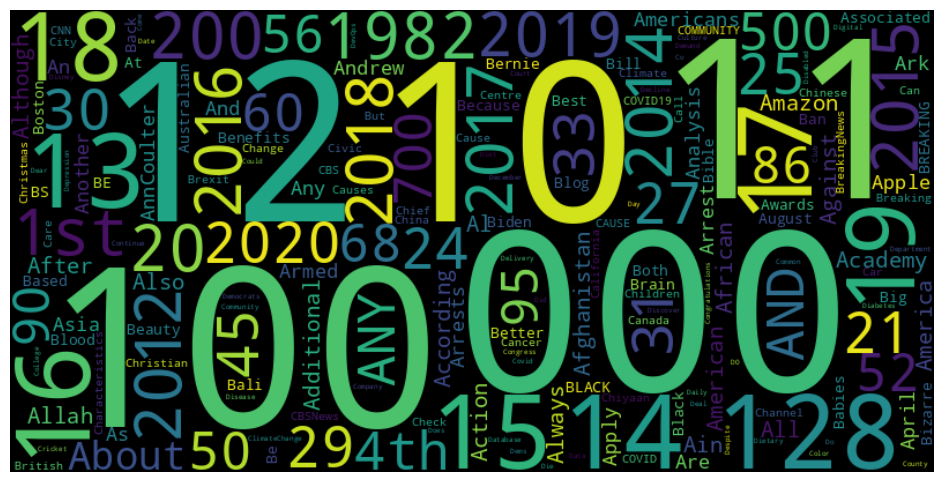

In [71]:
word_counts = Counter(vocabulaire)

wc = WordCloud(width=800, height=400)         # Creation du word cloud
wc.generate_from_frequencies(word_counts)     # Generation

plt.figure(figsize=(12, 6))                   # Affichage
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

wc.to_file("wordcloud2.png")

# Preparation

##Division de la data pour les tests


In [49]:
from sklearn.model_selection import train_test_split

Y = df[['science_related', 'scientific_claim', 'scientific_reference', 'scientific_context']]
print(Y.head())

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Variable entrainement:", X_train.shape)
print("Variable tests:", X_test.shape)
print("Variable entrainement resultat:", y_train.shape)
print("Variable entrainement resultat des tests:", y_test.shape)

   science_related  scientific_claim  scientific_reference  scientific_context
0                0               0.0                   0.0                 0.0
1                0               0.0                   0.0                 0.0
2                1               1.0                   0.0                 0.0
3                1               1.0                   0.0                 0.0
4                1               1.0                   0.0                 0.0
Variable entrainement: (912, 3129)
Variable tests: (228, 3129)
Variable entrainement resultat: (912, 4)
Variable entrainement resultat des tests: (228, 4)


## 1. Arbre de décision


In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

classifier = DecisionTreeClassifier(random_state=42)

classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)


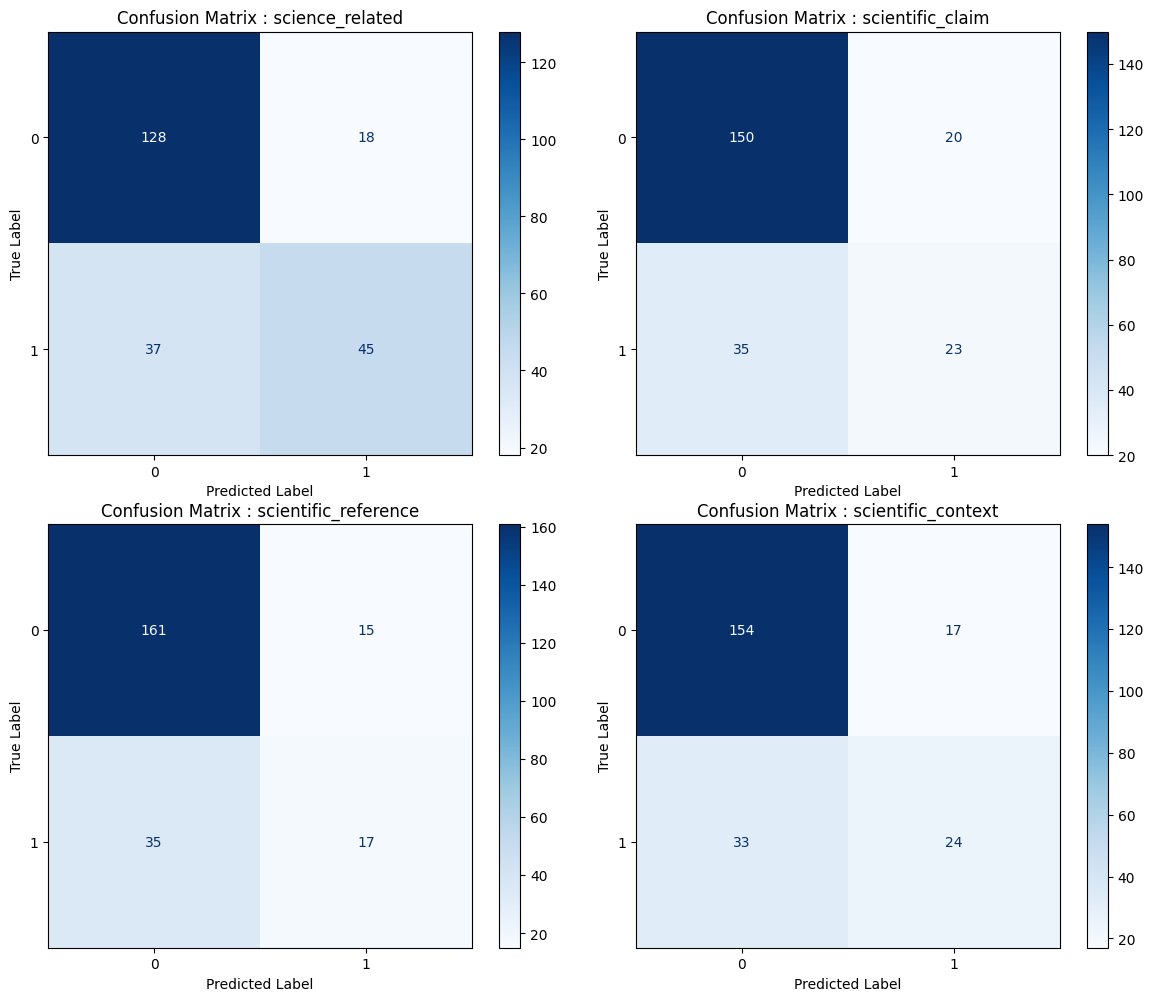

In [51]:

y_test_np = y_test.to_numpy()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, label in enumerate(y_test.columns):
    cm = confusion_matrix(y_test_np[:, i], y_pred[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues)
    axes[i].set_title(f'Confusion Matrix : {label}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

#En haut à gauche (True 0, Predicted 0)
#En haut à droite (True 0, Predicted 1)
#En bas à gauche (True 1, Predicted 0)
#En bas à droite (True 1, Predicted 1)
